In [95]:
print("Radiotherapy Image Quality Toolkit")

Radiotherapy Image Quality Toolkit


In [125]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print("Current folder:", Path.cwd())
print("Using src folder:", src_path)

Current folder: c:\Users\Yifen\OneDrive\Documents\GitHub\radiotherapy-image-quality-toolkit\notebook
Using src folder: c:\Users\Yifen\OneDrive\Documents\GitHub\radiotherapy-image-quality-toolkit\src


In [126]:
import pydicom
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as patches

from dicom_reader import load_dicom

from roi_analysis import (
    calculate_roi_statistics,
    calculate_snr,
    calculate_cnr,
    summarize_analysis
)

from visualization import (
    show_dicom_image,
    show_roi,
    show_two_rois
)

print("pydicom version:", pydicom.__version__)

pydicom version: 3.0.2


In [127]:
from pydicom.data import get_testdata_file

dicom_path = get_testdata_file("CT_small.dcm")

ds, image = load_dicom(dicom_path)

print(ds)

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 192
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.5962.1.1.1.1.1.20040119072730.12322
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.3.6.1.4.1.5962.2
(0002,0013) Implementation Version Name         SH: 'DCTOOL100'
(0002,0016) Source Application Entity Title     AE: 'CLUNIE1'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'AXIAL']
(0008,0012) Instance Creation Date              DA: '20040119'
(0008,0013) Instance Creation Time              TM: '072731'
(0008,0014) Instance Creator UID                UI: 1.3.6.1.4.

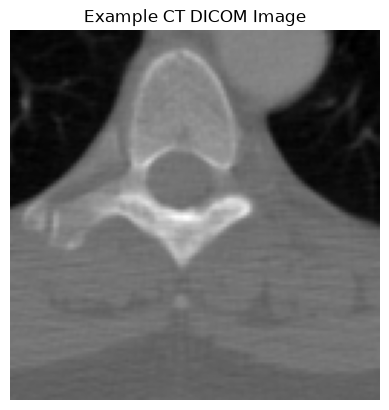

In [128]:
show_dicom_image(
    image,
    title="Example CT DICOM Image"
)

In [129]:
# Define a simple rectangular ROI
x1, x2 = 40, 80
y1, y2 = 40, 80


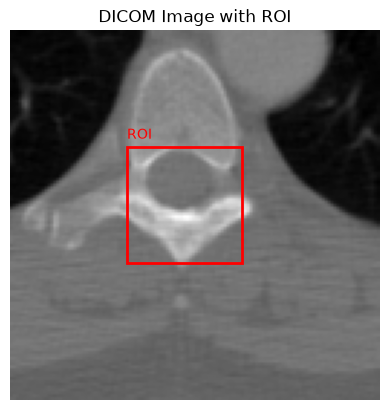

In [130]:
show_roi(
    image,
    x1, x2,
    y1, y2,
    label="ROI"
)

In [131]:
snr = roi_mean / roi_std

print("ROI SNR:", snr)

ROI SNR: 4.797610759076153


In [132]:
# Target ROI
roi_mean, roi_std = calculate_roi_statistics(
    image,
    x1, x2,
    y1, y2
)

snr = calculate_snr(
    image,
    x1, x2,
    y1, y2
)

print("ROI Mean:", roi_mean)
print("ROI SD:", roi_std)
print("SNR:", snr)

ROI Mean: 1307.86375
ROI SD: 272.6073071946853
SNR: 4.797610759076153


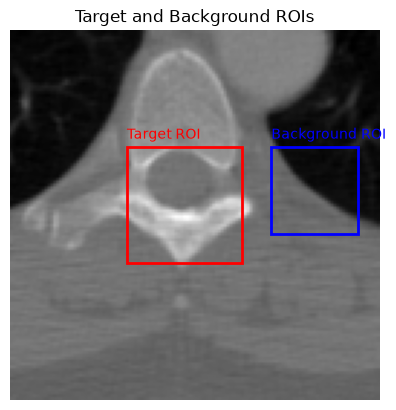

In [133]:
target_coords = (40, 80, 40, 80)
background_coords = (90, 120, 40, 70)

show_two_rois(
    image,
    target_coords,
    background_coords
)

In [139]:
results = summarize_analysis(
    image,
    target_coords,
    background_coords
)

for key, value in results.items():
    print(f"{key}: {value:.3f}")

Target Mean: 1307.864
Target SD: 272.607
Background Mean: 629.937
Background SD: 365.677
SNR: 4.798
CNR: 1.854


In [143]:
results_df = pd.DataFrame(
    list(results.items()),
    columns=["Metric", "Value"]
)

results_df

,Metric,Value
0,Target Mean,1307.863750
1,Target SD,272.607307
2,Background Mean,629.936667
3,Background SD,365.676620
4,SNR,4.797611
5,CNR,1.853898
